In [ ]:
# IMPORTANT: SOME KAGGLE DATA SOURCES ARE PRIVATE
# RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES.
import kagglehub
kagglehub.login()


In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.

subipinshapaulraj_english_path = kagglehub.dataset_download('subipinshapaulraj/english')

print('Data source import complete.')


In [ ]:
# Force update both to compatible versions
!pip install -U huggingface_hub transformers accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 625.2/625.2 kB 14.3 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 91.6 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 383.7/383.7 kB 24.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 114.1 MB/s eta 0:00:0000:01
  Attempting uninstall: hf-xet
    Found existing installation: hf-xet 1.3.0
    Uninstalling hf-xet-1.3.0:
      Successfully uninstalled hf-xet-1.3.0
  Attempting uninstall: huggingface_hub
    Found existing installation: huggingface_hub 1.4.1
    Uninstalling huggingface_hub-1.4.1:
      Successfully uninstalled huggingface_hub-1.4.1
  Attempting uninstall: accelerate
    Found existing installation: accelerate 1.12.0
    Uninstalling accelerate-1.12.0:
      Successfully uninstalled accelerate-1.12.0
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully unins

In [ ]:
import torch
from datasets import load_dataset, concatenate_datasets
from transformers import Qwen2VLForConditionalGeneration, AutoProcessor
from transformers import BitsAndBytesConfig
from PIL import Image

In [ ]:
!pip install sentence-transformers faiss-cpu pymupdf nltk tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 76.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.9/24.9 MB 76.3 MB/s eta 0:00:00:00:0100:01


In [ ]:
import fitz
import faiss
import nltk
import numpy as np
from tqdm import tqdm
from sentence_transformers import SentenceTransformer
from nltk.tokenize import sent_tokenize

nltk.download("punkt")

[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [ ]:
colbert_model = SentenceTransformer("colbert-ir/colbertv2.0")

No sentence-transformers model found with name colbert-ir/colbertv2.0. Creating a new one with mean pooling.


config.json:   0%|          | 0.00/743 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: colbert-ir/colbertv2.0
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 
linear.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/405 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

In [ ]:
def extract_pdf_text(pdf_path):

    doc = fitz.open(pdf_path)

    pages_text = []

    for page in doc:

        text = page.get_text()

        pages_text.append(text)

    return pages_text

In [ ]:
pdf_path = "/kaggle/input/datasets/subipinshapaulraj/english/science_english.pdf"

pages = extract_pdf_text(pdf_path)

print("Pages:", len(pages))

Pages: 200


In [ ]:

from nltk.tokenize import sent_tokenize

def chunk_text(text, max_sentences=5):

    print("\n==============================")
    print("TEXT CHUNKING PROCESS")
    print("==============================")

    # Step 1: Sentence tokenization
    sentences = sent_tokenize(text)

    print("\n--- Sentence Tokenization ---")
    print("Total sentences:", len(sentences))

    for i, s in enumerate(sentences[:5]):
        print(f"Sentence {i}:", s)

    chunks = []

    # Step 2: Create chunks
    print("\n--- Creating Chunks ---")

    for i in range(0, len(sentences), max_sentences):

        chunk = " ".join(sentences[i:i+max_sentences])

        print("\nChunk index:", len(chunks))
        print("Sentence range:", i, "to", i+max_sentences-1)
        print("Chunk text:", chunk[:120], "...")

        chunks.append(chunk)

    # Step 3: Final chunk list
    print("\n--- Final Chunk Summary ---")
    print("Total chunks created:", len(chunks))

    for i, c in enumerate(chunks[:3]):
        print(f"\nChunk {i} preview:", c[:150], "...")

    return chunks


In [ ]:
documents = []

metadata = []

for page_id, page in enumerate(pages):

    chunks = chunk_text(page)

    for chunk in chunks:

        documents.append(chunk)

        metadata.append(page_id)

print("Total chunks:", len(documents))


TEXT CHUNKING PROCESS

--- Sentence Tokenization ---
Total sentences: 1
Sentence 0: SCIENCE 
SOCIAL SCIENCE
A publication under Free Textbook Programme of Government of Tamil Nadu
Department of School Education
Untouchability is Inhuman and a Crime
STANDARD SEVEN
TERM - I
VOLUME - 3
GOVERNMENT OF TAMIL NADU
VII Std Science Term-1 EM Introduction Pages.indd   1
12/9/2022   12:04:14 PM
www.tntextbooks.in

--- Creating Chunks ---

Chunk index: 0
Sentence range: 0 to 4
Chunk text: SCIENCE 
SOCIAL SCIENCE
A publication under Free Textbook Programme of Government of Tamil Nadu
Department of School Edu ...

--- Final Chunk Summary ---
Total chunks created: 1

Chunk 0 preview: SCIENCE 
SOCIAL SCIENCE
A publication under Free Textbook Programme of Government of Tamil Nadu
Department of School Education
Untouchability is Inhum ...

TEXT CHUNKING PROCESS

--- Sentence Tokenization ---
Total sentences: 1
Sentence 0: Government of Tamil Nadu
First Edition 
- 
2019
Revised Edition 
- 
2020, 2022, 2

In [ ]:
doc_embeddings = colbert_model.encode(
    documents,
    convert_to_numpy=True,
    batch_size=64,
    normalize_embeddings=True,
    show_progress_bar=True
)

Batches:   0%|          | 0/17 [00:00<?, ?it/s]

In [ ]:
dimension = doc_embeddings.shape[1]

index = faiss.IndexFlatIP(dimension)

index.add(doc_embeddings)

print("Indexed chunks:", index.ntotal)

Indexed chunks: 1051


In [ ]:

import numpy as np

def retrieve_candidates(query, top_k=20):

    print("\n==============================")
    print("TEXT RETRIEVAL STAGE")
    print("==============================")

    print("\nQuery:", query)

    # Step 1: Encode query
    print("\n--- Encoding Query ---")

    query_emb = colbert_model.encode(
        query,
        convert_to_numpy=True,
        normalize_embeddings=True
    )

    print("Query embedding shape:", query_emb.shape)
    print("First 10 embedding values:", query_emb[:10])

    # Step 2: Search vector index
    print("\n--- Searching Vector Index ---")

    scores, indices = index.search(
        np.array([query_emb]),
        top_k
    )

    print("Scores shape:", scores.shape)
    print("Indices shape:", indices.shape)

    print("\nTop scores:")
    print(scores[0][:10])

    print("\nTop indices:")
    print(indices[0][:10])

    # Step 3: Retrieve candidate chunks
    print("\n--- Retrieving Candidate Chunks ---")

    candidates = []

    for rank, idx in enumerate(indices[0]):

        text_chunk = documents[idx]
        page_num = metadata[idx]

        print(f"\nCandidate {rank}")
        print("Document index:", idx)
        print("Page:", page_num)
        print("Text preview:", text_chunk[:120], "...")

        candidates.append({
            "text": text_chunk,
            "page": page_num
        })

    print("\nTotal candidates retrieved:", len(candidates))

    return candidates



In [ ]:

import numpy as np

def colbert_rerank(query, candidates):

    print("\n==============================")
    print("COLBERT RERANKING STAGE")
    print("==============================")

    print("\nQuery:", query)
    print("Number of candidates:", len(candidates))

    # Step 1: Encode query
    print("\n--- Encoding Query ---")

    query_emb = colbert_model.encode(query)

    print("Query embedding shape:", np.array(query_emb).shape)
    print("First 10 values:", query_emb[:10])

    # Step 2: Collect candidate texts
    texts = [c["text"] for c in candidates]

    print("\n--- Candidate Texts ---")
    for i, t in enumerate(texts[:3]):
        print(f"\nCandidate {i} preview:", t[:120], "...")

    # Step 3: Encode documents
    print("\n--- Encoding Candidate Texts ---")

    doc_embs = colbert_model.encode(texts)

    print("Document embeddings shape:", np.array(doc_embs).shape)

    scores = []

    # Step 4: Compute similarity
    print("\n--- Computing Similarity Scores ---")

    for i, emb in enumerate(doc_embs):

        score = np.dot(query_emb, emb)

        print(f"Candidate {i} score:", score)

        scores.append(score)

    # Step 5: Sort by score
    ranked = sorted(
        zip(candidates, scores),
        key=lambda x: x[1],
        reverse=True
    )

    print("\n--- Ranking Results ---")

    for i, (cand, score) in enumerate(ranked[:5]):

        print(f"\nRank {i+1}")
        print("Score:", score)
        print("Page:", cand["page"])
        print("Text preview:", cand["text"][:120], "...")

    return ranked



In [ ]:
def colbert_text_retrieval(query):

    # Step 1: retrieve
    candidates = retrieve_candidates(query, top_k=20)

    # Step 2: rerank
    ranked = colbert_rerank(query, candidates)

    return ranked[:5]

In [ ]:
query = "What is pollination?"

results = colbert_text_retrieval(query)

for rank,(item,score) in enumerate(results):

    print("Rank:", rank+1)
    print("Score:", score)
    print("Page:", item["page"])
    print(item["text"])
    print()


TEXT RETRIEVAL STAGE

Query: What is pollination?

--- Encoding Query ---
Query embedding shape: (768,)
First 10 embedding values: [ 0.01309844 -0.01077014  0.00347739 -0.02042878  0.00092693  0.03913438
  0.02646079  0.0490821  -0.01524876 -0.03235853]

--- Searching Vector Index ---
Scores shape: (1, 20)
Indices shape: (1, 20)

Top scores:
[0.7180371  0.7173351  0.6960416  0.6805339  0.67640203 0.6761094
 0.67035687 0.6603937  0.6555661  0.64350224]

Top indices:
[ 403  406  412  398  350  418  351  995 1031  337]

--- Retrieving Candidate Chunks ---

Candidate 0
Document index: 403
Page: 74
Text preview: 2. The transfer of pollen to the stigma is known 
as pollination. 3. Conical shaped root is carrot. 4. ...

Candidate 1
Document index: 406
Page: 74
Text preview: Define – Pollination. 4. What are the agents of pollination? 5. Give example for  Corm and Tuber
6. ...

Candidate 2
Document index: 412
Page: 74
Text preview: Agents like wind, water, insects and animals 
are helpful fo

In [ ]:
query = "What is derived quantities?"

results = colbert_text_retrieval(query)

for rank,(item,score) in enumerate(results):

    print("Rank:", rank+1)
    print("Score:", score)
    print("Page:", item["page"])
    print(item["text"])
    print()


TEXT RETRIEVAL STAGE

Query: What is derived quantities?

--- Encoding Query ---
Query embedding shape: (768,)
First 10 embedding values: [ 0.04237874 -0.0108475  -0.02576017  0.02841407  0.02978222  0.06302907
 -0.03259353 -0.00695202  0.00197282  0.02079067]

--- Searching Vector Index ---
Scores shape: (1, 20)
Indices shape: (1, 20)

Top scores:
[0.80918604 0.79029435 0.74361753 0.7285606  0.72537255 0.7122928
 0.695209   0.6879668  0.6767815  0.6762657 ]

Top indices:
[   9   73   12   54 1031  995 1032   13 1004  994]

--- Retrieving Candidate Chunks ---

Candidate 0
Document index: 9
Page: 5
Text preview: 2
1.1.2 Derived quantities
All other physical quantities which can be 
obtained by multiplying, dividing or by 
mathemat ...

Candidate 1
Document index: 73
Page: 14
Text preview: What are derived quantities? 2. Distinguish between the volume of liquid 
and capacity of a container. 3. Define the den ...

Candidate 2
Document index: 12
Page: 5
Text preview: In this example 
‘2’ 

In [ ]:
def build_context(results):

    context = "\n\n".join(

        item["text"]

        for item,score in results

    )

    return context

In [ ]:
context = build_context(results)

print(context)

What are derived quantities? 2. Distinguish between the volume of liquid 
and capacity of a container. 3. Define the density of objects.

2
1.1.2 Derived quantities
All other physical quantities which can be 
obtained by multiplying, dividing or by 
mathematically combining the fundamental 
quantities are known as derived quantities. Eg. Area and volume. Their corresponding units 
are called derived units. Some of the derived 
quantities and their units are given in Table 1.2.

What is production? 2. What is utility? 3. Name the types of utility.

In this example 
‘2’ is the value and ‘kilometre’ is the unit used 
to express the magnitude of distance which 
is a physical quantity. In this lesson, we are 
going to study about fundamental quantities, 
derived  quantities such as area, volume and 
density, and measurement of larger quantities. 1.1   Fundamental Quantities and   
Derived Quantities
Generally, physical quantities are classified 
into two types. They are: fundamental quantit

In [ ]:
!pip install torch torchvision pillow tqdm pymupdf matplotlib
!pip install colpali_engine

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 110.7/110.7 kB 4.4 MB/s eta 0:00:00


In [ ]:
!pip install -U transformers accelerate

In [ ]:
!pip install huggingface_hub==0.23.2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 401.7/401.7 kB 8.2 MB/s eta 0:00:00:00:01
  Attempting uninstall: huggingface_hub
    Found existing installation: huggingface_hub 1.8.0
    Uninstalling huggingface_hub-1.8.0:
      Successfully uninstalled huggingface_hub-1.8.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
transformers 5.4.0 requires huggingface-hub<2.0,>=1.5.0, but you have huggingface-hub 0.23.2 which is incompatible.
datasets 4.8.3 requires huggingface-hub<2.0,>=0.25.0, but you have huggingface-hub 0.23.2 which is incompatible.
peft 0.18.1 requires huggingface_hub>=0.25.0, but you have huggingface-hub 0.23.2 which is incompatible.
diffusers 0.36.0 requires huggingface-hub<2.0,>=0.34.0, but you have huggingface-hub 0.23.2 which is incompatible.
gradio 5.50.0 requires huggingface-hub<2.0,>=0.33.5, but you have huggingface-hub 0.23.2 which is inco

In [ ]:
import os
import fitz
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm
from collections import deque
from transformers import AutoProcessor
from colpali_engine.models import ColQwen2

In [ ]:
MAX_GEN_TOKENS = 200
# Patch grid resolution
GRID_SIZE = 14

# Threshold for saliency mask
SAL_THRESHOLD = 0.35

# Neighbor distance for grouping
NEIGHBOR_RANGE = 1

# Max generator tokens
MAX_GEN_TOKENS = 200

# Number of pages retrieved globally
TOP_K_PAGES = 3

# Paths
PDF_PATH = "/kaggle/input/datasets/subipinshapaulraj/english/science_english.pdf"

PAGE_IMAGE_DIR = "/kaggle/working/page_images"
REGION_DIR = "/kaggle/working/regions"

os.makedirs(PAGE_IMAGE_DIR, exist_ok=True)
os.makedirs(REGION_DIR, exist_ok=True)



In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

print("Running on:", device)

Running on: cuda


In [ ]:
print("Loading Region Retriever Model")

retriever = ColQwen2.from_pretrained(
    "vidore/colqwen2-v0.1",
    torch_dtype=torch.float16
).to(device).eval()

retriever_processor = AutoProcessor.from_pretrained("vidore/colqwen2-v0.1")

Loading Region Retriever Model


adapter_config.json:   0%|          | 0.00/728 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/392 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/613 [00:00<?, ?B/s]

In [ ]:
import fitz
from PIL import Image
from tqdm import tqdm

def pdf_to_images(pdf_path):

    print("Opening PDF:", pdf_path)

    doc = fitz.open(pdf_path)

    print("Total pages in document:", len(doc))

    images = []

    print("\nRendering pages...\n")

    for page_idx in tqdm(range(len(doc))):

        page = doc[page_idx]

        print("\n-----------------------------------")
        print("Processing Page:", page_idx)

        # render page
        pix = page.get_pixmap(matrix=fitz.Matrix(400/72,400/72))

        print("Rendered Pixmap Info:")
        print("Width:", pix.width)
        print("Height:", pix.height)
        print("Channels:", pix.n)
        print("Pixel Data Length:", len(pix.samples))

        # convert to image
        img = Image.frombytes(
            "RGB",
            [pix.width, pix.height],
            pix.samples
        )

        print("Converted to PIL Image")
        print("Image Mode:", img.mode)
        print("Image Size:", img.size)

        images.append(img)

    print("\nTotal images generated:", len(images))

    return images

In [ ]:


pages = pdf_to_images(PDF_PATH)

print("Total pages:", len(pages))

Opening PDF: /kaggle/input/datasets/subipinshapaulraj/english/science_english.pdf
Total pages in document: 200

Rendering pages...



  0%|          | 0/200 [00:00<?, ?it/s]


-----------------------------------
Processing Page: 0
Rendered Pixmap Info:
Width: 3635
Height: 4895
Channels: 3
Pixel Data Length: 53379975


  0%|          | 1/200 [00:00<00:48,  4.15it/s]

Converted to PIL Image
Image Mode: RGB
Image Size: (3635, 4895)

-----------------------------------
Processing Page: 1
Rendered Pixmap Info:
Width: 3635
Height: 4895
Channels: 3
Pixel Data Length: 53379975


...

Converted to PIL Image
Image Mode: RGB
Image Size: (3635, 4895)

-----------------------------------
Processing Page: 198
Rendered Pixmap Info:
Width: 3635
Height: 4895
Channels: 3
Pixel Data Length: 53379975


100%|█████████▉| 199/200 [00:57<00:00,  3.62it/s]

Converted to PIL Image
Image Mode: RGB
Image Size: (3635, 4895)

-----------------------------------
Processing Page: 199
Rendered Pixmap Info:
Width: 3635
Height: 5005
Channels: 3
Pixel Data Length: 54579525


100%|██████████| 200/200 [00:58<00:00,  3.44it/s]

Converted to PIL Image
Image Mode: RGB
Image Size: (3635, 5005)

Total images generated: 200
Total pages: 200


In [ ]:
import torch
from tqdm import tqdm

def compute_page_embeddings(pages):

    page_embeddings = []

    for i, img in enumerate(tqdm(pages)):

        debug = i < 10

        if debug:
            print("\n==============================")
            print(f"Processing Page {i}")
            print("==============================")

        # ✅ Step 1: Proper multimodal preprocessing (FIXED)
        inputs = retriever_processor.process_images([img]).to(device)

        # ✅ CRITICAL FIX: add mm_token_type_ids
        inputs["mm_token_type_ids"] = torch.zeros_like(inputs["input_ids"]).to(device)

        if debug:
            print("\n--- Preprocessed Inputs ---")
            for k, v in inputs.items():
                print(f"{k} shape:", v.shape)
                print(f"{k} sample:", v.flatten()[:10])

        # ✅ Step 2: Forward pass
        with torch.no_grad():
            emb = retriever(**inputs)



        if debug:
            print("\n--- Raw Model Output ---")
            print("Shape:", emb.shape)
            print("First token vector:", emb[0, 0, :10])

            print("\nMeaning:")
            print("Batch size:", emb.shape[0])
            print("Tokens:", emb.shape[1])
            print("Embedding dim:", emb.shape[2])

        # ✅ Step 3: Mean pooling
        emb = emb.mean(dim=1)

        if debug:
            print("\n--- After Mean Pooling ---")
            print("Shape:", emb.shape)
            print("Values:", emb[0, :10])

        # ✅ Step 4: Remove batch dimension
        emb = emb.squeeze().float().cpu()

        if debug:
            print("\n--- After Squeeze ---")
            print("Shape:", emb.shape)
            print("Values:", emb[:10])

        # ✅ Step 5: Normalize
        norm = emb.norm()
        emb = emb / norm

        if debug:
            print("\n--- Normalized Embedding ---")
            print("Norm:", emb.norm().item())
            print("Values:", emb[:10])

        page_embeddings.append(emb)

    # ✅ Stack all embeddings
    page_embeddings = torch.stack(page_embeddings)

    print("\n==============================")
    print("Final Page Embedding Matrix")
    print("==============================")
    print("Shape:", page_embeddings.shape)
    print("First embedding sample:", page_embeddings[0, :10])

    return page_embeddings

In [ ]:
page_embeddings = compute_page_embeddings(pages)

print(page_embeddings.shape)

  0%|          | 0/200 [00:00<?, ?it/s]


Processing Page 0

--- Preprocessed Inputs ---
input_ids shape: torch.Size([1, 747])
input_ids sample: tensor([151644,    872,    198, 151652, 151655, 151655, 151655, 151655, 151655,
        151655], device='cuda:0')
attention_mask shape: torch.Size([1, 747])
attention_mask sample: tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1], device='cuda:0')
pixel_values shape: torch.Size([1, 2944, 1176])
pixel_values sample: tensor([1.9303, 1.9303, 1.9303, 1.9303, 1.9303, 1.9303, 1.9303, 1.9303, 1.9303,
        1.9303], device='cuda:0')
image_grid_thw shape: torch.Size([1, 3])
image_grid_thw sample: tensor([ 1, 64, 46], device='cuda:0')
mm_token_type_ids shape: torch.Size([1, 747])
mm_token_type_ids sample: tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0], device='cuda:0')


  0%|          | 1/200 [00:03<10:22,  3.13s/it]


--- Raw Model Output ---
Shape: torch.Size([1, 747, 128])
First token vector: tensor([-0.0216, -0.0456, -0.0448,  0.1189, -0.0599, -0.0184,  0.0198,  0.1779,
        -0.0119, -0.0050], device='cuda:0', dtype=torch.float16)

Meaning:
Batch size: 1
Tokens: 747
Embedding dim: 128

--- After Mean Pooling ---
Shape: torch.Size([1, 128])
Values: tensor([ 0.0025,  0.0309,  0.0565,  0.0637,  0.0462, -0.0080, -0.0620,  0.0091,
        -0.0199,  0.0774], device='cuda:0', dtype=torch.float16)

--- After Squeeze ---
Shape: torch.Size([128])
Values: tensor([ 0.0025,  0.0309,  0.0565,  0.0637,  0.0462, -0.0080, -0.0620,  0.0091,
        -0.0199,  0.0774])

--- Normalized Embedding ---
Norm: 0.9999999403953552
Values: tensor([ 0.0064,  0.0790,  0.1441,  0.1624,  0.1179, -0.0204, -0.1581,  0.0232,
        -0.0508,  0.1975])

Processing Page 1

--- Preprocessed Inputs ---
input_ids shape: torch.Size([1, 747])
input_ids sample: tensor([151644,    872,    198, 151652, 151655, 151655, 151655, 151655, 151

  1%|          | 2/200 [00:04<06:01,  1.82s/it]

...


--- Raw Model Output ---
Shape: torch.Size([1, 747, 128])
First token vector: tensor([-0.0216, -0.0456, -0.0448,  0.1189, -0.0599, -0.0184,  0.0198,  0.1779,
        -0.0119, -0.0050], device='cuda:0', dtype=torch.float16)

Meaning:
Batch size: 1
Tokens: 747
Embedding dim: 128

--- After Mean Pooling ---
Shape: torch.Size([1, 128])
Values: tensor([ 0.0816, -0.0402,  0.0473,  0.0113,  0.0244,  0.0117, -0.1217, -0.0308,
         0.0361,  0.0710], device='cuda:0', dtype=torch.float16)

--- After Squeeze ---
Shape: torch.Size([128])
Values: tensor([ 0.0816, -0.0402,  0.0473,  0.0113,  0.0244,  0.0117, -0.1217, -0.0308,
         0.0361,  0.0710])

--- Normalized Embedding ---
Norm: 1.0
Values: tensor([ 0.1914, -0.0943,  0.1109,  0.0264,  0.0573,  0.0274, -0.2854, -0.0721,
         0.0847,  0.1665])

Processing Page 9

--- Preprocessed Inputs ---
input_ids shape: torch.Size([1, 747])
input_ids sample: tensor([151644,    872,    198, 151652, 151655, 151655, 151655, 151655, 151655,
        15

  5%|▌         | 10/200 [00:10<02:42,  1.17it/s]


--- Raw Model Output ---
Shape: torch.Size([1, 747, 128])
First token vector: tensor([-0.0216, -0.0456, -0.0448,  0.1189, -0.0599, -0.0184,  0.0198,  0.1779,
        -0.0119, -0.0050], device='cuda:0', dtype=torch.float16)

Meaning:
Batch size: 1
Tokens: 747
Embedding dim: 128

--- After Mean Pooling ---
Shape: torch.Size([1, 128])
Values: tensor([ 0.0823, -0.0228,  0.0535,  0.0366, -0.0195,  0.0184, -0.0656, -0.0631,
         0.0058,  0.0522], device='cuda:0', dtype=torch.float16)

--- After Squeeze ---
Shape: torch.Size([128])
Values: tensor([ 0.0823, -0.0228,  0.0535,  0.0366, -0.0195,  0.0184, -0.0656, -0.0631,
         0.0058,  0.0522])

--- Normalized Embedding ---
Norm: 1.0
Values: tensor([ 0.2171, -0.0602,  0.1411,  0.0964, -0.0515,  0.0484, -0.1729, -0.1664,
         0.0154,  0.1375])


100%|██████████| 200/200 [02:57<00:00,  1.13it/s]


Final Page Embedding Matrix
Shape: torch.Size([200, 128])
First embedding sample: tensor([ 0.0064,  0.0790,  0.1441,  0.1624,  0.1179, -0.0204, -0.1581,  0.0232,
        -0.0508,  0.1975])
torch.Size([200, 128])


In [ ]:

import torch

def compute_query_embedding(query):

    print("\n==============================")
    print("Processing Query")
    print("==============================")
    print("Query:", query)

    # Step 1: Query preprocessing
    inputs = retriever_processor.process_queries([query])

    print("\n--- Preprocessed Query Tensor ---")
    for k, v in inputs.items():
        print(f"{k} shape:", v.shape)
        print(f"{k} sample values:", v.flatten()[:10])

    # Move tensors to device
    inputs = {k: v.to(device) for k, v in inputs.items()}

    # Step 2: Forward pass through model
    with torch.no_grad():
        emb = retriever(**inputs)

    print("\n--- Raw Model Output ---")
    print("Shape:", emb.shape)
    print("First token vector (first 10 values):")
    print(emb[0,0,:10])

    print("\nMeaning:")
    print("Batch size:", emb.shape[0])
    print("Number of tokens:", emb.shape[1])
    print("Embedding dimension:", emb.shape[2])

    # Step 3: Mean pooling
    emb = emb.mean(dim=1)

    print("\n--- After Mean Pooling ---")
    print("Shape:", emb.shape)
    print("First 10 values:", emb[0,:10])

    # Step 4: Remove batch dimension
    emb = emb.squeeze().float().cpu()

    print("\n--- After Squeeze ---")
    print("Shape:", emb.shape)
    print("First 10 values:", emb[:10])

    # Step 5: Norm calculation
    norm_val = emb.norm()

    print("\n--- Vector Norm ---")
    print("Norm value:", norm_val.item())

    # Step 6: Normalize embedding
    emb = emb / norm_val

    print("\n--- Normalized Query Embedding ---")
    print("Shape:", emb.shape)
    print("First 10 values:", emb[:10])

    return emb

In [ ]:
def show_pages(pages,indices):

    plt.figure(figsize=(15,5))

    for i,idx in enumerate(indices):

        plt.subplot(1,len(indices),i+1)

        plt.imshow(pages[idx])

        plt.axis("off")

        plt.title(f"Page {idx}")

    plt.show()

In [ ]:

import torch

def retrieve_pages(query, page_embeddings, top_k=3):

    print("\n==============================")
    print("Retrieval Stage")
    print("==============================")

    # Step 1: Compute query embedding
    print("\n--- Computing Query Embedding ---")
    q_emb = compute_query_embedding(query)

    print("\nQuery embedding shape:", q_emb.shape)
    print("First 10 values:", q_emb[:10])

    # Step 2: Page embedding matrix
    print("\n--- Page Embedding Matrix ---")
    print("Shape:", page_embeddings.shape)
    print("Example page embedding (first page):")
    print(page_embeddings[0,:10])

    # Step 3: Compute similarity scores
    print("\n--- Computing Similarity Scores ---")
    scores = torch.matmul(page_embeddings, q_emb)

    print("Scores shape:", scores.shape)
    print("First 10 scores:", scores[:50])

    # Step 4: Top-K retrieval
    print("\n--- Selecting Top Pages ---")
    topk = torch.topk(scores, top_k)

    print("Top indices:", topk.indices)
    print("Top scores:", topk.values)

    return topk.indices.tolist(), scores



Retrieval Stage

--- Computing Query Embedding ---

Processing Query
Query: Elements in human body

--- Preprocessed Query Tensor ---
input_ids shape: torch.Size([1, 16])
input_ids sample values: tensor([  2859,     25,  34157,    304,   3738,   2487, 151643, 151643, 151643,
        151643])
attention_mask shape: torch.Size([1, 16])
attention_mask sample values: tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

--- Raw Model Output ---
Shape: torch.Size([1, 16, 128])
First token vector (first 10 values):
tensor([-0.0755, -0.0150, -0.0121,  0.1058, -0.0818, -0.0316,  0.0426,  0.1794,
        -0.0278,  0.0027], device='cuda:0', dtype=torch.float16)

Meaning:
Batch size: 1
Number of tokens: 16
Embedding dimension: 128

--- After Mean Pooling ---
Shape: torch.Size([1, 128])
First 10 values: tensor([ 0.1213, -0.0068,  0.1034, -0.0627, -0.0101,  0.0494, -0.0373,  0.0011,
         0.0666, -0.0300], device='cuda:0', dtype=torch.float16)

--- After Squeeze ---
Shape: torch.Size([128])
First 10 values: t

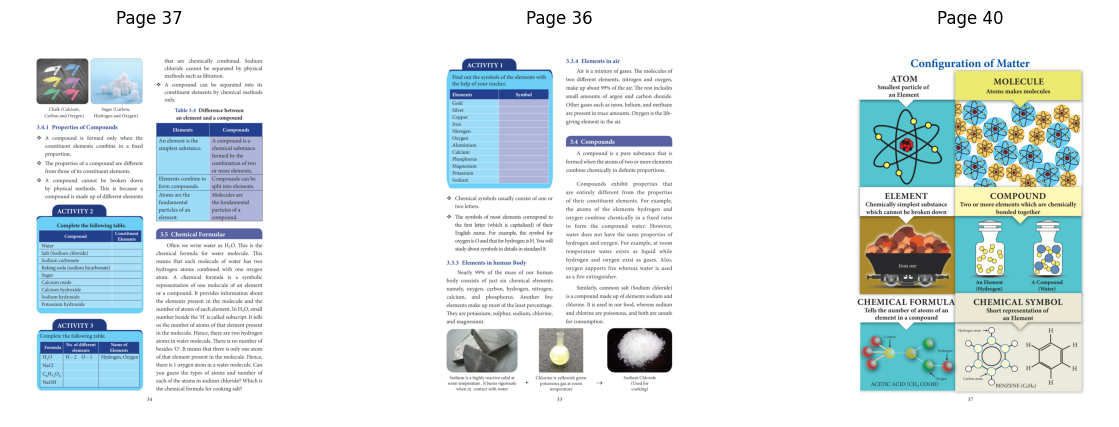

In [ ]:
query = "Elements in human body"

top_pages,scores = retrieve_pages(query,page_embeddings)

print("Retrieved pages:",top_pages)

show_pages(pages,top_pages)


Query: Explain pollination in plants

Retrieval Stage

--- Computing Query Embedding ---

Processing Query
Query: Explain pollination in plants

--- Preprocessed Query Tensor ---
input_ids shape: torch.Size([1, 17])
input_ids sample values: tensor([  2859,     25,  81917,   7085,   2554,    304,  10779, 151643, 151643,
        151643])
attention_mask shape: torch.Size([1, 17])
attention_mask sample values: tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

--- Raw Model Output ---
Shape: torch.Size([1, 17, 128])
First token vector (first 10 values):
tensor([-0.0757, -0.0149, -0.0122,  0.1060, -0.0817, -0.0316,  0.0423,  0.1797,
        -0.0278,  0.0028], device='cuda:0', dtype=torch.float16)

Meaning:
Batch size: 1
Number of tokens: 17
Embedding dimension: 128

--- After Mean Pooling ---
Shape: torch.Size([1, 128])
First 10 values: tensor([ 0.1033,  0.0091,  0.1609, -0.0142,  0.0146, -0.0130,  0.0865, -0.0707,
         0.0608, -0.0431], device='cuda:0', dtype=torch.float16)

--- After Squeeze --

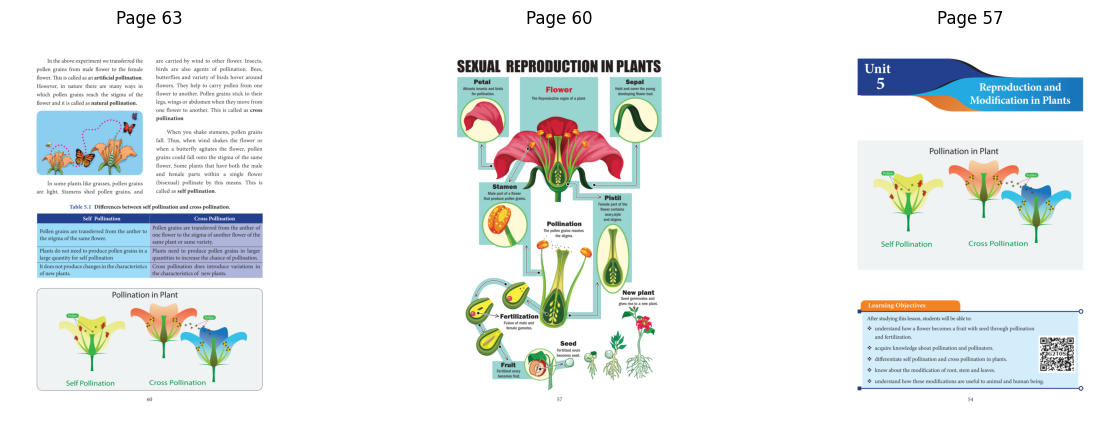


Query: 3D cubes

Retrieval Stage

--- Computing Query Embedding ---

Processing Query
Query: 3D cubes

--- Preprocessed Query Tensor ---
input_ids shape: torch.Size([1, 16])
input_ids sample values: tensor([  2859,     25,    220,     18,     35,  54104, 151643, 151643, 151643,
        151643])
attention_mask shape: torch.Size([1, 16])
attention_mask sample values: tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

--- Raw Model Output ---
Shape: torch.Size([1, 16, 128])
First token vector (first 10 values):
tensor([-0.0755, -0.0150, -0.0121,  0.1058, -0.0818, -0.0316,  0.0426,  0.1794,
        -0.0278,  0.0027], device='cuda:0', dtype=torch.float16)

Meaning:
Batch size: 1
Number of tokens: 16
Embedding dimension: 128

--- After Mean Pooling ---
Shape: torch.Size([1, 128])
First 10 values: tensor([-0.0370, -0.0143,  0.0175, -0.0017,  0.0441,  0.0406, -0.0464, -0.0234,
        -0.0008, -0.0257], device='cuda:0', dtype=torch.float16)

--- After Squeeze ---
Shape: torch.Size([128])
First 10 values

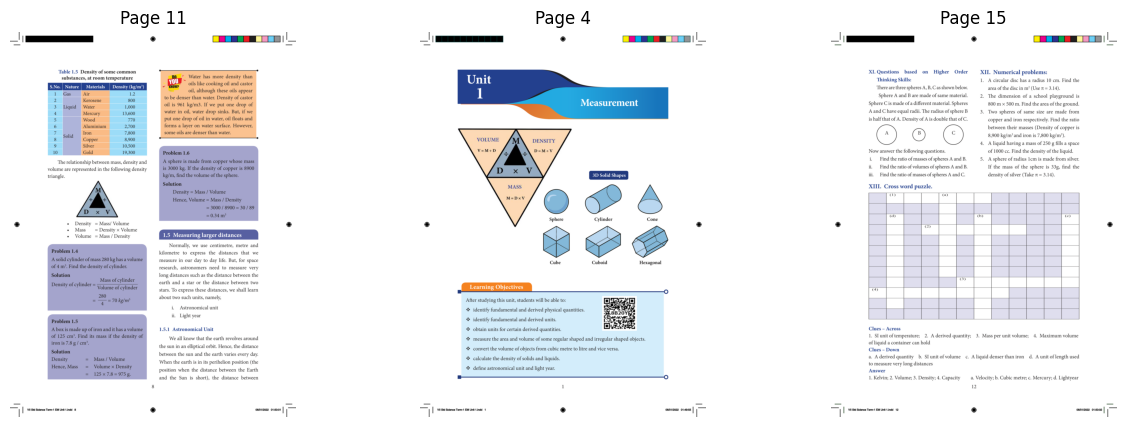


Query: Explain Hepatitis virus

Retrieval Stage

--- Computing Query Embedding ---

Processing Query
Query: Explain Hepatitis virus

--- Preprocessed Query Tensor ---
input_ids shape: torch.Size([1, 16])
input_ids sample values: tensor([  2859,     25,  81917,  60145,  81701,  16770, 151643, 151643, 151643,
        151643])
attention_mask shape: torch.Size([1, 16])
attention_mask sample values: tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

--- Raw Model Output ---
Shape: torch.Size([1, 16, 128])
First token vector (first 10 values):
tensor([-0.0755, -0.0150, -0.0121,  0.1058, -0.0818, -0.0316,  0.0426,  0.1794,
        -0.0278,  0.0027], device='cuda:0', dtype=torch.float16)

Meaning:
Batch size: 1
Number of tokens: 16
Embedding dimension: 128

--- After Mean Pooling ---
Shape: torch.Size([1, 128])
First 10 values: tensor([-0.0951,  0.0228,  0.0809,  0.0453,  0.0736,  0.0416,  0.0157,  0.0482,
        -0.1205, -0.0234], device='cuda:0', dtype=torch.float16)

--- After Squeeze ---
Shape: tor

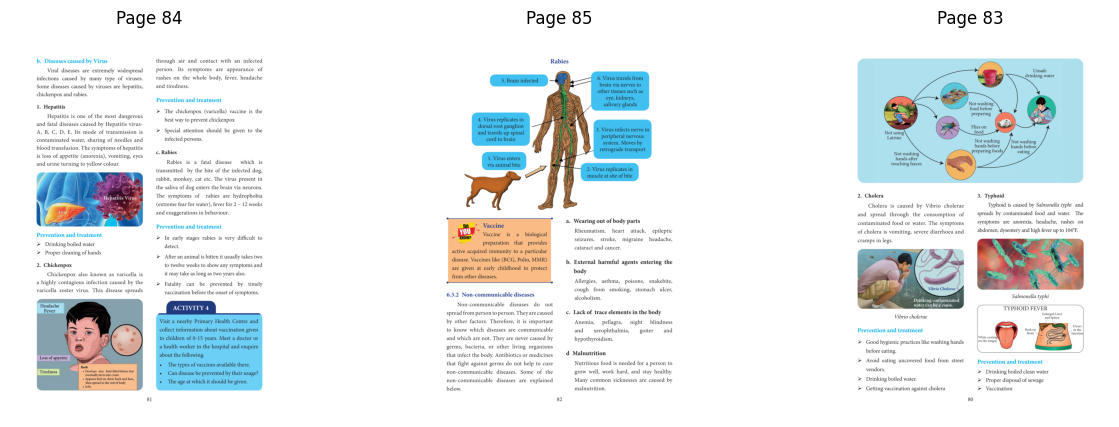


Query: characteristics of Hibiscus flower 

Retrieval Stage

--- Computing Query Embedding ---

Processing Query
Query: characteristics of Hibiscus flower 

--- Preprocessed Query Tensor ---
input_ids shape: torch.Size([1, 19])
input_ids sample values: tensor([  2859,     25,  17452,    315,  91736,   3427,    355,  22351,    220,
        151643])
attention_mask shape: torch.Size([1, 19])
attention_mask sample values: tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

--- Raw Model Output ---
Shape: torch.Size([1, 19, 128])
First token vector (first 10 values):
tensor([-0.0757, -0.0149, -0.0122,  0.1060, -0.0817, -0.0316,  0.0423,  0.1797,
        -0.0278,  0.0028], device='cuda:0', dtype=torch.float16)

Meaning:
Batch size: 1
Number of tokens: 19
Embedding dimension: 128

--- After Mean Pooling ---
Shape: torch.Size([1, 128])
First 10 values: tensor([-0.0559, -0.0531, -0.0488, -0.0153, -0.0876,  0.0402,  0.0267, -0.0514,
        -0.0349,  0.0102], device='cuda:0', dtype=torch.float16)

--- Afte

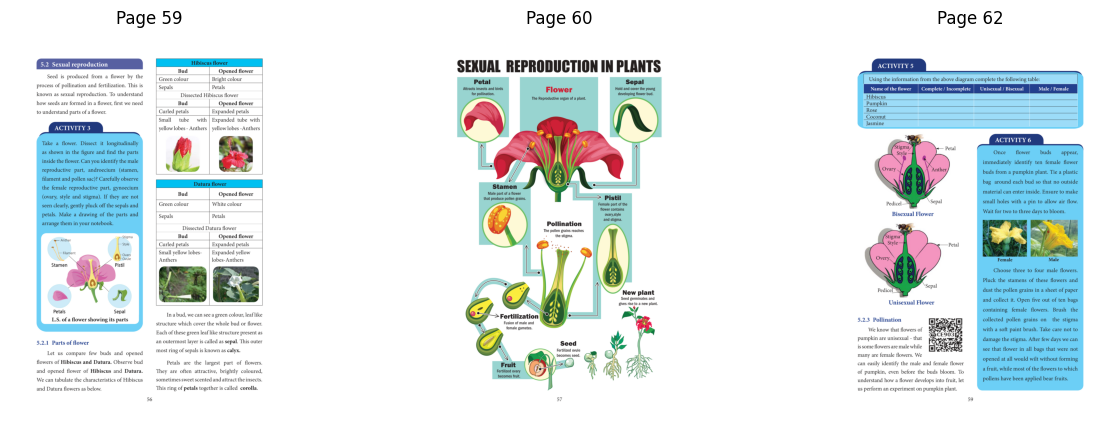

In [ ]:
queries = [
"Explain pollination in plants",
"3D cubes",
"Explain Hepatitis virus",
 "characteristics of Hibiscus flower " #107
]

for q in queries:

    print("\nQuery:", q)

    top_pages, scores = retrieve_pages(q, page_embeddings)

    print("Retrieved pages:", top_pages)

    show_pages(pages, top_pages)

In [ ]:
!pip install spire.pdf

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.5/42.5 MB 45.2 MB/s eta 0:00:00:00:0100:01
  Attempting uninstall: plum-dispatch
    Found existing installation: plum-dispatch 2.7.1
    Uninstalling plum-dispatch-2.7.1:
      Successfully uninstalled plum-dispatch-2.7.1


In [ ]:
import fitz
import os

def extract_images_from_pages(pdf_path, output_dir, page_numbers):

    os.makedirs(output_dir, exist_ok=True)

    doc = fitz.open(pdf_path)
    image_paths = []

    for page_number in page_numbers:

        # ⚠️ Adjust indexing if needed
        page = doc[page_number-1]   # or page_number - 1

        image_list = page.get_images(full=True)

        for i, img in enumerate(image_list):

            xref = img[0]
            base_image = doc.extract_image(xref)

            # ✅ Filter small images
            if base_image["width"] < 100 or base_image["height"] < 100:
                continue

            image_bytes = base_image["image"]
            image_ext = base_image["ext"]

            image_path = os.path.join(
                output_dir,
                f"page-{page_number}-img-{i}.{image_ext}"
            )

            with open(image_path, "wb") as f:
                f.write(image_bytes)

            image_paths.append(image_path)

    return image_paths

In [ ]:
from PIL import Image
import torch

def compute_image_embeddings(image_paths):

    embeddings = []

    for path in image_paths:

        img = Image.open(path).convert("RGB")

        # ✅ Correct processor usage
        inputs = retriever_processor.process_images([img]).to(device)

        # ✅ Ensure input_ids exist (CRITICAL FIX)
        if "input_ids" not in inputs:
            seq_len = inputs["pixel_values"].shape[1]

            inputs["input_ids"] = torch.zeros((1, seq_len), dtype=torch.long).to(device)
            inputs["attention_mask"] = torch.ones((1, seq_len), dtype=torch.long).to(device)

        # ✅ Fix mm_token_type_ids to MATCH input_ids length
        seq_len = inputs["input_ids"].shape[1]

        inputs["mm_token_type_ids"] = torch.zeros(
            (1, seq_len), dtype=torch.long
        ).to(device)

        with torch.no_grad():
            emb = retriever(**inputs)

        emb = emb.mean(dim=1).squeeze().cpu()
        emb = emb / emb.norm()

        embeddings.append(emb)

    return torch.stack(embeddings)

In [ ]:
def rank_images(query, image_embeddings, image_paths, top_k=3):

    q_emb = compute_query_embedding(query)

    # 🔥 FIX: match dtype + device
    q_emb = q_emb.to(image_embeddings.device).to(image_embeddings.dtype)

    scores = torch.matmul(image_embeddings, q_emb)

    topk = torch.topk(scores, top_k)

    results = [(image_paths[i], scores[i].item()) for i in topk.indices]

    return results

In [ ]:
from IPython.display import Image as IPImage, display

def show_images(results):

    for path, score in results:
        print("\nScore:", score)
        display(IPImage(filename=path))


Query: Explain pollination in plants

Retrieval Stage

--- Computing Query Embedding ---

Processing Query
Query: Explain pollination in plants

--- Preprocessed Query Tensor ---
input_ids shape: torch.Size([1, 17])
input_ids sample values: tensor([  2859,     25,  81917,   7085,   2554,    304,  10779, 151643, 151643,
        151643])
attention_mask shape: torch.Size([1, 17])
attention_mask sample values: tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

--- Raw Model Output ---
Shape: torch.Size([1, 17, 128])
First token vector (first 10 values):
tensor([-0.0757, -0.0149, -0.0122,  0.1060, -0.0817, -0.0316,  0.0423,  0.1797,
        -0.0278,  0.0028], device='cuda:0', dtype=torch.float16)

Meaning:
Batch size: 1
Number of tokens: 17
Embedding dimension: 128

--- After Mean Pooling ---
Shape: torch.Size([1, 128])
First 10 values: tensor([ 0.1033,  0.0091,  0.1609, -0.0142,  0.0146, -0.0130,  0.0865, -0.0707,
         0.0608, -0.0431], device='cuda:0', dtype=torch.float16)

--- After Squeeze --

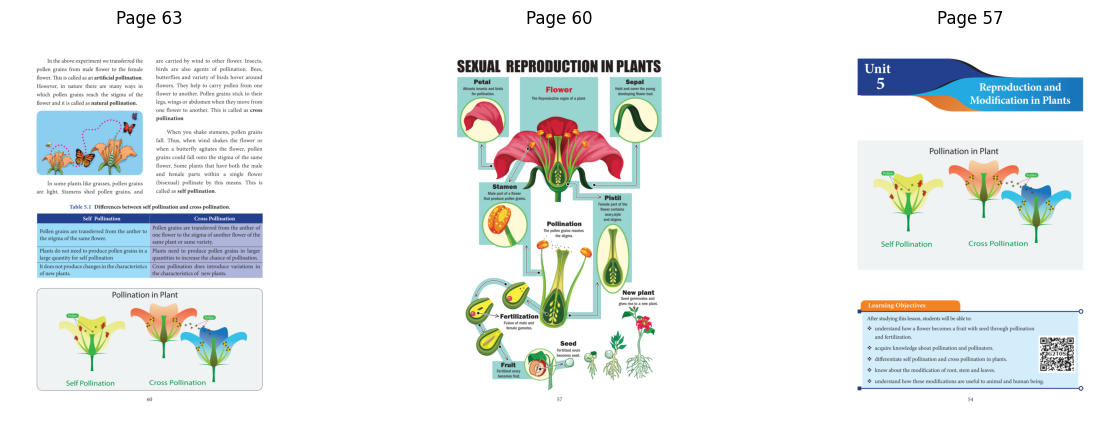

Total images extracted: 16

Processing Query
Query: Explain pollination in plants

--- Preprocessed Query Tensor ---
input_ids shape: torch.Size([1, 17])
input_ids sample values: tensor([  2859,     25,  81917,   7085,   2554,    304,  10779, 151643, 151643,
        151643])
attention_mask shape: torch.Size([1, 17])
attention_mask sample values: tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

--- Raw Model Output ---
Shape: torch.Size([1, 17, 128])
First token vector (first 10 values):
tensor([-0.0757, -0.0149, -0.0122,  0.1060, -0.0817, -0.0316,  0.0423,  0.1797,
        -0.0278,  0.0028], device='cuda:0', dtype=torch.float16)

Meaning:
Batch size: 1
Number of tokens: 17
Embedding dimension: 128

--- After Mean Pooling ---
Shape: torch.Size([1, 128])
First 10 values: tensor([ 0.1033,  0.0091,  0.1609, -0.0142,  0.0146, -0.0130,  0.0865, -0.0707,
         0.0608, -0.0431], device='cuda:0', dtype=torch.float16)

--- After Squeeze ---
Shape: torch.Size([128])
First 10 values: tensor([ 0.1033,  0

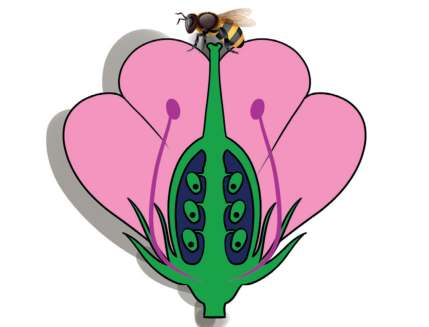


Score: 0.327880859375


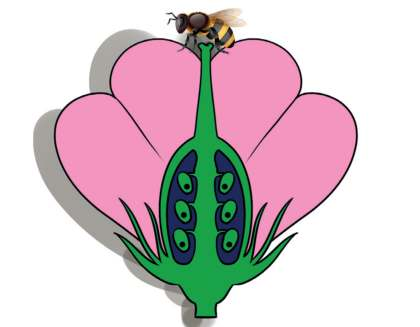


Score: 0.2200927734375


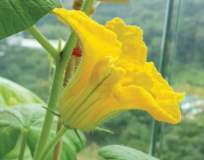


Query: 3D cubes

Retrieval Stage

--- Computing Query Embedding ---

Processing Query
Query: 3D cubes

--- Preprocessed Query Tensor ---
input_ids shape: torch.Size([1, 16])
input_ids sample values: tensor([  2859,     25,    220,     18,     35,  54104, 151643, 151643, 151643,
        151643])
attention_mask shape: torch.Size([1, 16])
attention_mask sample values: tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

--- Raw Model Output ---
Shape: torch.Size([1, 16, 128])
First token vector (first 10 values):
tensor([-0.0755, -0.0150, -0.0121,  0.1058, -0.0818, -0.0316,  0.0426,  0.1794,
        -0.0278,  0.0027], device='cuda:0', dtype=torch.float16)

Meaning:
Batch size: 1
Number of tokens: 16
Embedding dimension: 128

--- After Mean Pooling ---
Shape: torch.Size([1, 128])
First 10 values: tensor([-0.0370, -0.0143,  0.0175, -0.0017,  0.0441,  0.0406, -0.0464, -0.0234,
        -0.0008, -0.0257], device='cuda:0', dtype=torch.float16)

--- After Squeeze ---
Shape: torch.Size([128])
First 10 values

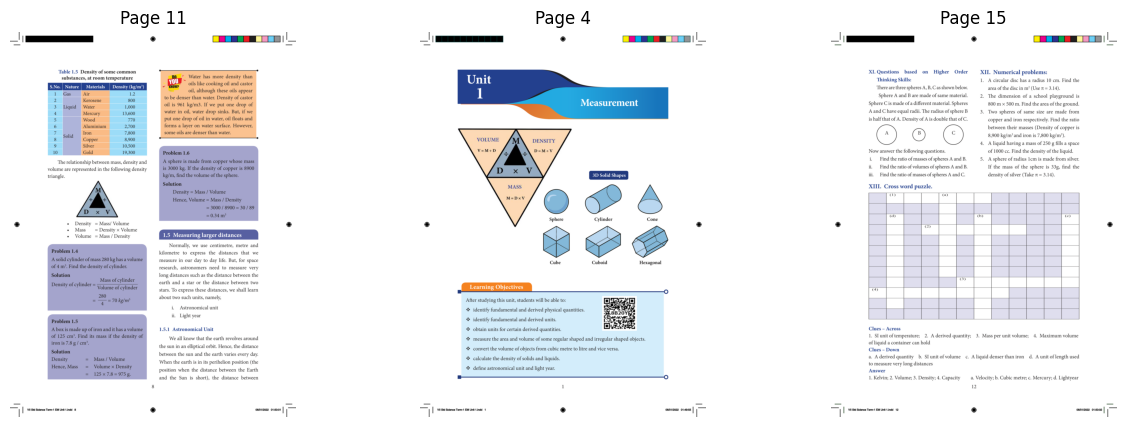

Total images extracted: 5

Processing Query
Query: 3D cubes

--- Preprocessed Query Tensor ---
input_ids shape: torch.Size([1, 16])
input_ids sample values: tensor([  2859,     25,    220,     18,     35,  54104, 151643, 151643, 151643,
        151643])
attention_mask shape: torch.Size([1, 16])
attention_mask sample values: tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

--- Raw Model Output ---
Shape: torch.Size([1, 16, 128])
First token vector (first 10 values):
tensor([-0.0755, -0.0150, -0.0121,  0.1058, -0.0818, -0.0316,  0.0426,  0.1794,
        -0.0278,  0.0027], device='cuda:0', dtype=torch.float16)

Meaning:
Batch size: 1
Number of tokens: 16
Embedding dimension: 128

--- After Mean Pooling ---
Shape: torch.Size([1, 128])
First 10 values: tensor([-0.0370, -0.0143,  0.0175, -0.0017,  0.0441,  0.0406, -0.0464, -0.0234,
        -0.0008, -0.0257], device='cuda:0', dtype=torch.float16)

--- After Squeeze ---
Shape: torch.Size([128])
First 10 values: tensor([-0.0370, -0.0143,  0.0175, -0.001

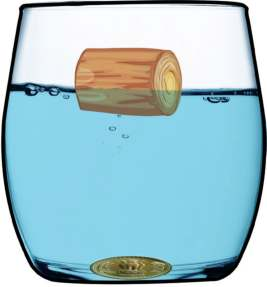


Score: 0.161865234375


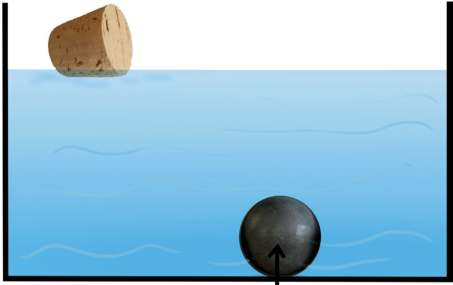


Score: 0.1317138671875


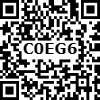


Query: Explain Hepatitis virus

Retrieval Stage

--- Computing Query Embedding ---

Processing Query
Query: Explain Hepatitis virus

--- Preprocessed Query Tensor ---
input_ids shape: torch.Size([1, 16])
input_ids sample values: tensor([  2859,     25,  81917,  60145,  81701,  16770, 151643, 151643, 151643,
        151643])
attention_mask shape: torch.Size([1, 16])
attention_mask sample values: tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

--- Raw Model Output ---
Shape: torch.Size([1, 16, 128])
First token vector (first 10 values):
tensor([-0.0755, -0.0150, -0.0121,  0.1058, -0.0818, -0.0316,  0.0426,  0.1794,
        -0.0278,  0.0027], device='cuda:0', dtype=torch.float16)

Meaning:
Batch size: 1
Number of tokens: 16
Embedding dimension: 128

--- After Mean Pooling ---
Shape: torch.Size([1, 128])
First 10 values: tensor([-0.0951,  0.0228,  0.0809,  0.0453,  0.0736,  0.0416,  0.0157,  0.0482,
        -0.1205, -0.0234], device='cuda:0', dtype=torch.float16)

--- After Squeeze ---
Shape: tor

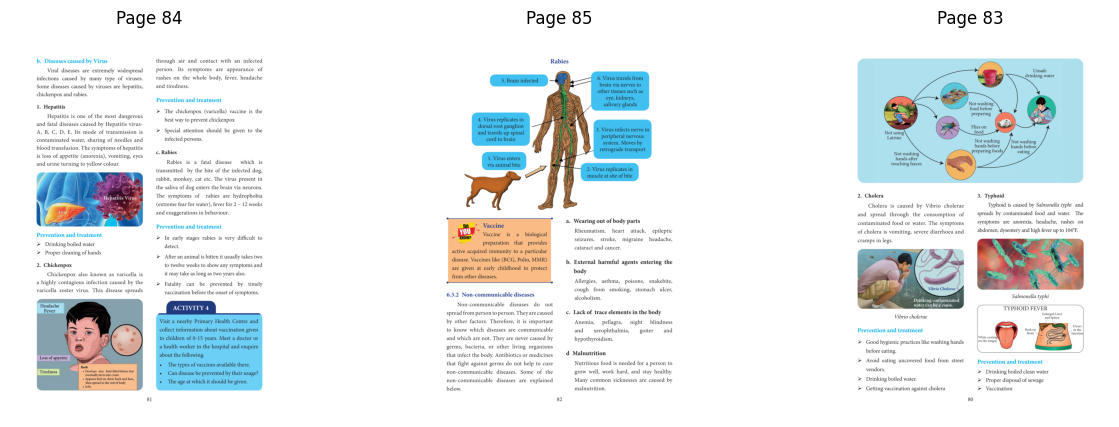

Total images extracted: 20

Processing Query
Query: Explain Hepatitis virus

--- Preprocessed Query Tensor ---
input_ids shape: torch.Size([1, 16])
input_ids sample values: tensor([  2859,     25,  81917,  60145,  81701,  16770, 151643, 151643, 151643,
        151643])
attention_mask shape: torch.Size([1, 16])
attention_mask sample values: tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

--- Raw Model Output ---
Shape: torch.Size([1, 16, 128])
First token vector (first 10 values):
tensor([-0.0755, -0.0150, -0.0121,  0.1058, -0.0818, -0.0316,  0.0426,  0.1794,
        -0.0278,  0.0027], device='cuda:0', dtype=torch.float16)

Meaning:
Batch size: 1
Number of tokens: 16
Embedding dimension: 128

--- After Mean Pooling ---
Shape: torch.Size([1, 128])
First 10 values: tensor([-0.0951,  0.0228,  0.0809,  0.0453,  0.0736,  0.0416,  0.0157,  0.0482,
        -0.1205, -0.0234], device='cuda:0', dtype=torch.float16)

--- After Squeeze ---
Shape: torch.Size([128])
First 10 values: tensor([-0.0951,  0.0228,

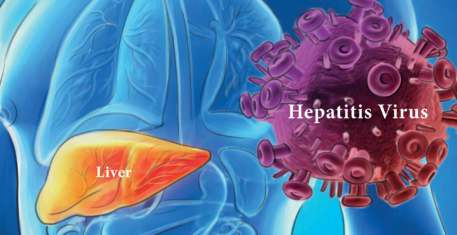


Score: 0.3154296875


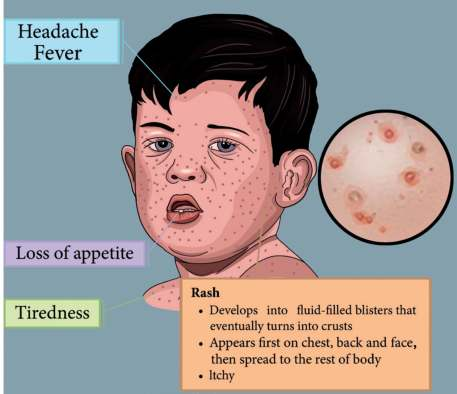


Score: 0.284912109375


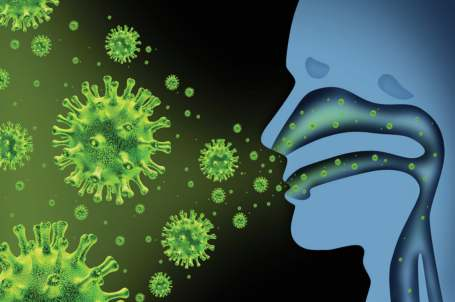


Query: characteristics of Hibiscus flower 

Retrieval Stage

--- Computing Query Embedding ---

Processing Query
Query: characteristics of Hibiscus flower 

--- Preprocessed Query Tensor ---
input_ids shape: torch.Size([1, 19])
input_ids sample values: tensor([  2859,     25,  17452,    315,  91736,   3427,    355,  22351,    220,
        151643])
attention_mask shape: torch.Size([1, 19])
attention_mask sample values: tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

--- Raw Model Output ---
Shape: torch.Size([1, 19, 128])
First token vector (first 10 values):
tensor([-0.0757, -0.0149, -0.0122,  0.1060, -0.0817, -0.0316,  0.0423,  0.1797,
        -0.0278,  0.0028], device='cuda:0', dtype=torch.float16)

Meaning:
Batch size: 1
Number of tokens: 19
Embedding dimension: 128

--- After Mean Pooling ---
Shape: torch.Size([1, 128])
First 10 values: tensor([-0.0559, -0.0531, -0.0488, -0.0153, -0.0876,  0.0402,  0.0267, -0.0514,
        -0.0349,  0.0102], device='cuda:0', dtype=torch.float16)

--- Afte

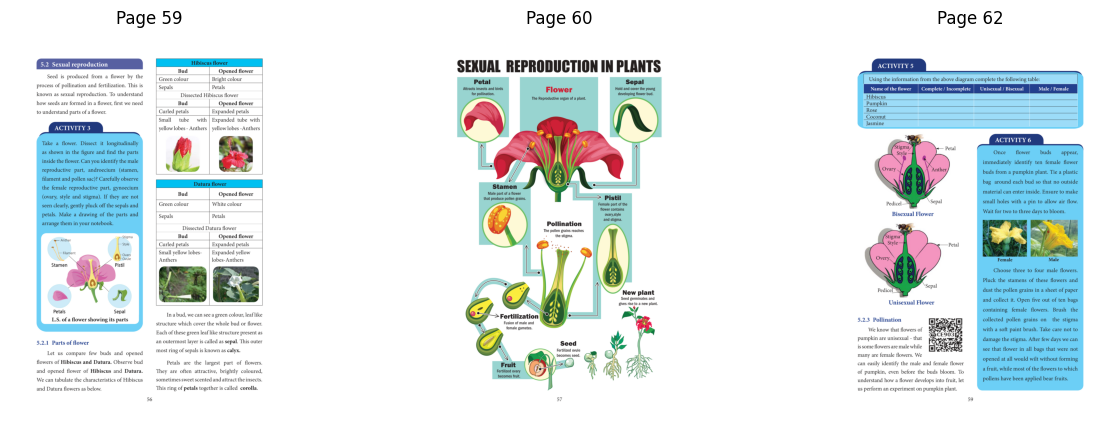

Total images extracted: 10

Processing Query
Query: characteristics of Hibiscus flower 

--- Preprocessed Query Tensor ---
input_ids shape: torch.Size([1, 19])
input_ids sample values: tensor([  2859,     25,  17452,    315,  91736,   3427,    355,  22351,    220,
        151643])
attention_mask shape: torch.Size([1, 19])
attention_mask sample values: tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

--- Raw Model Output ---
Shape: torch.Size([1, 19, 128])
First token vector (first 10 values):
tensor([-0.0757, -0.0149, -0.0122,  0.1060, -0.0817, -0.0316,  0.0423,  0.1797,
        -0.0278,  0.0028], device='cuda:0', dtype=torch.float16)

Meaning:
Batch size: 1
Number of tokens: 19
Embedding dimension: 128

--- After Mean Pooling ---
Shape: torch.Size([1, 128])
First 10 values: tensor([-0.0559, -0.0531, -0.0488, -0.0153, -0.0876,  0.0402,  0.0267, -0.0514,
        -0.0349,  0.0102], device='cuda:0', dtype=torch.float16)

--- After Squeeze ---
Shape: torch.Size([128])
First 10 values: tensor([-0.05

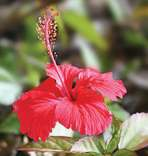


Score: 0.49365234375


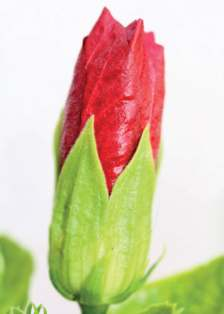


Score: 0.464111328125


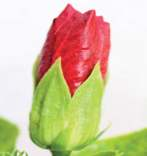

In [ ]:
for q in queries:

    print("\nQuery:", q)

    top_pages, scores = retrieve_pages(q, page_embeddings)

    print("Retrieved pages:", top_pages)

    show_pages(pages, top_pages)

    # 🔥 NEW PART STARTS HERE

    # Step 1: Extract images
    image_paths = extract_images_from_pages(
        "/kaggle/input/datasets/subipinshapaulraj/english/science_english.pdf",
        "./images",
        top_pages
    )

    print("Total images extracted:", len(image_paths))

    if len(image_paths) == 0:
        print("No images found")
        continue

    # Step 2: Compute image embeddings
    image_embeddings = compute_image_embeddings(image_paths)

    # Step 3: Rank images
    results = rank_images(q, image_embeddings, image_paths)

    # Step 4: Show best images
    print("\nTop Relevant Images:")
    show_images(results)